# 📊 MindBridge — Exploratory Data Analysis
### Step 2: Understanding the Data

> **Goal:** Explore the dataset to uncover patterns, class distributions, text characteristics, and key insights before modeling.

---

| Section | What We Explore |
|---------|----------------|
| 📦 Dataset Overview | Shape, types, missing values |
| 📊 Class Distribution | Balance across 7 mental health classes |
| 📏 Text Length Analysis | Word and character count patterns |
| ☁️ Word Clouds | Most frequent words per class |
| 🔍 Key Insights | Summary of findings |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("darkgrid")

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [2]:
df = pd.read_csv('/Users/vaibhav2040/Desktop/MIND_BRIDGE/data/Combined Data.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.columns = ['statement', 'status']
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df = df.reset_index(drop=True)

print("=" * 55)
print("         📊 MINDBRIDGE — DATASET OVERVIEW")
print("=" * 55)
print(f"  Total Samples     : {len(df):,}")
print(f"  Total Columns     : {df.shape[1]}")
print(f"  Missing Values    : {df.isnull().sum().sum()}")
print(f"  Duplicate Rows    : {df.duplicated().sum():,}")
print(f"  Unique Classes    : {df['status'].nunique()}")
print("=" * 55)
print(f"\n🏷️  Classes:\n")
for i, cls in enumerate(sorted(df['status'].unique()), 1):
    count = df['status'].value_counts()[cls]
    pct = count / len(df) * 100
    bar = "█" * int(pct / 2)
    print(f"   {i}. {cls:<25} {bar} {pct:.1f}%")
print("=" * 55)

         📊 MINDBRIDGE — DATASET OVERVIEW
  Total Samples     : 51,093
  Total Columns     : 2
  Missing Values    : 0
  Duplicate Rows    : 0
  Unique Classes    : 7

🏷️  Classes:

   1. Anxiety                   ███ 7.1%
   2. Bipolar                   ██ 4.9%
   3. Depression                ██████████████ 29.5%
   4. Normal                    ███████████████ 31.4%
   5. Personality disorder       1.8%
   6. Stress                    ██ 4.5%
   7. Suicidal                  ██████████ 20.8%


In [3]:
html = """
<div style="
    background: linear-gradient(135deg, #1a1a2e, #16213e, #0f3460);
    border-radius: 16px;
    padding: 28px 36px;
    font-family: 'Segoe UI', sans-serif;
    color: white;
    border-left: 6px solid #6C63FF;
    margin: 10px 0;
">
    <h2 style="color:#6C63FF; margin-bottom:4px;">📊 Dataset at a Glance</h2>
    <p style="color:#aaa; font-size:13px; margin-bottom:20px;">MindBridge EDA — Step 2</p>
    <table style="width:100%; border-collapse:collapse; text-align:center;">
        <tr>
            <td style="padding:16px; background:rgba(108,99,255,0.15); border-radius:10px; width:25%;">
                <div style="font-size:32px;">📝</div>
                <div style="font-size:22px; font-weight:bold; color:#6C63FF;">53K+</div>
                <div style="color:#aaa; font-size:13px;">Total Samples</div>
            </td>
            <td style="width:2%;"></td>
            <td style="padding:16px; background:rgba(72,202,228,0.1); border-radius:10px; width:25%;">
                <div style="font-size:32px;">🏷️</div>
                <div style="font-size:22px; font-weight:bold; color:#48CAE4;">7</div>
                <div style="color:#aaa; font-size:13px;">Mental Health Classes</div>
            </td>
            <td style="width:2%;"></td>
            <td style="padding:16px; background:rgba(6,214,160,0.1); border-radius:10px; width:25%;">
                <div style="font-size:32px;">✅</div>
                <div style="font-size:22px; font-weight:bold; color:#06d6a0;">0</div>
                <div style="color:#aaa; font-size:13px;">Missing Values</div>
            </td>
            <td style="width:2%;"></td>
            <td style="padding:16px; background:rgba(247,37,133,0.1); border-radius:10px; width:25%;">
                <div style="font-size:32px;">🔤</div>
                <div style="font-size:22px; font-weight:bold; color:#f72585;">2</div>
                <div style="color:#aaa; font-size:13px;">Features</div>
            </td>
        </tr>
    </table>
</div>
"""
display(HTML(html))

📝 53K+ Total Samples,,🏷️ 7 Mental Health Classes,,✅ 0 Missing Values,,🔤 2 Features


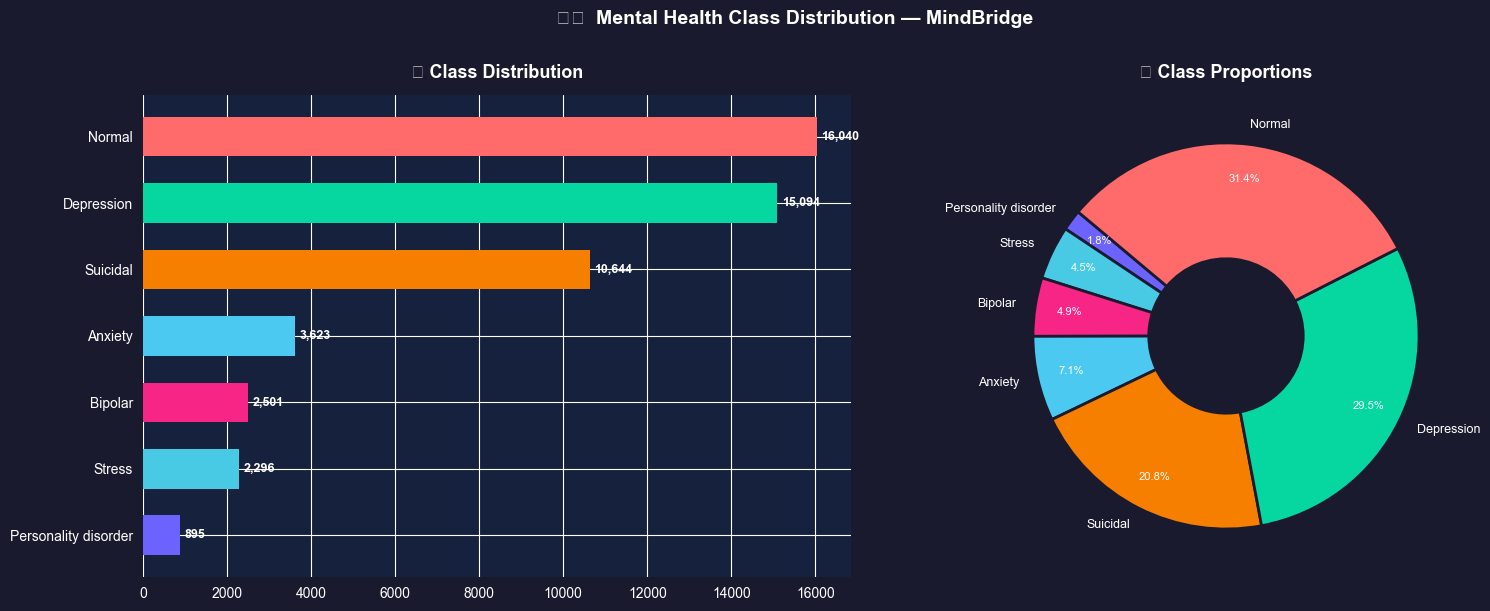

✅ Saved!


In [5]:
COLORS = ['#6C63FF','#48CAE4','#f72585','#4cc9f0','#f77f00','#06d6a0','#ff6b6b']
class_counts = df['status'].value_counts().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#1a1a2e')

# Bar Chart
ax1 = axes[0]
ax1.set_facecolor('#16213e')
bars = ax1.barh(class_counts.index, class_counts.values,
                color=COLORS, height=0.6, edgecolor='none')
for bar, val in zip(bars, class_counts.values):
    ax1.text(val + 100, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', color='white', fontsize=9, fontweight='bold')
ax1.set_title('📊 Class Distribution', color='white', fontsize=13, fontweight='bold', pad=12)
ax1.tick_params(colors='white')
ax1.spines[['top','right','bottom','left']].set_visible(False)
for label in ax1.get_yticklabels():
    label.set_color('white')

# Pie Chart
ax2 = axes[1]
ax2.set_facecolor('#16213e')
wedges, texts, autotexts = ax2.pie(
    class_counts.values,
    labels=class_counts.index,
    colors=COLORS,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(width=0.6, edgecolor='#1a1a2e', linewidth=2)
)
for text in texts:
    text.set_color('white')
    text.set_fontsize(9)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(8)
ax2.set_title('🥧 Class Proportions', color='white', fontsize=13, fontweight='bold', pad=12)

plt.suptitle('🏷️  Mental Health Class Distribution — MindBridge',
             color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/Users/vaibhav2040/Desktop/MIND_BRIDGE/results/plots/01_class_distribution.png',
            dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("✅ Saved!")

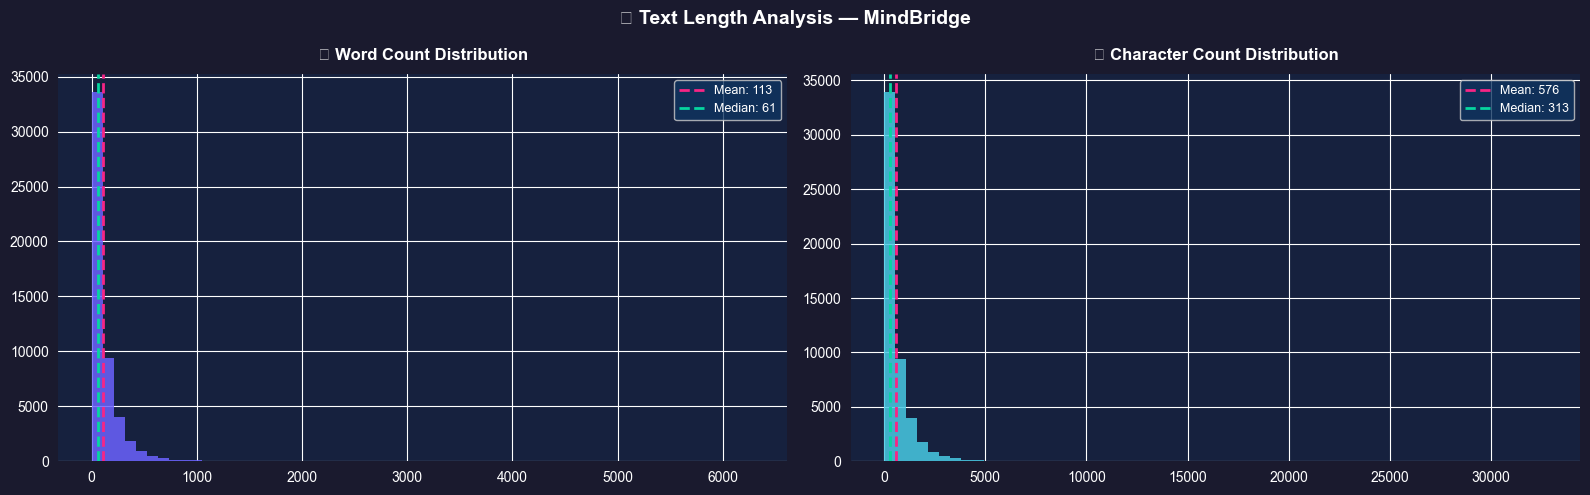

  Avg words  : 112.7
  Avg chars  : 575.6
  Max words  : 6300
✅ Saved!


In [6]:
df['word_count'] = df['statement'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['statement'].apply(lambda x: len(str(x)))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#1a1a2e')

for ax, col, title, color in zip(
    axes,
    ['word_count', 'char_count'],
    ['📏 Word Count Distribution', '🔤 Character Count Distribution'],
    ['#6C63FF', '#48CAE4']
):
    ax.set_facecolor('#16213e')
    ax.hist(df[col], bins=60, color=color, alpha=0.85, edgecolor='none')
    ax.axvline(df[col].mean(), color='#f72585', linestyle='--', linewidth=2,
               label=f'Mean: {df[col].mean():.0f}')
    ax.axvline(df[col].median(), color='#06d6a0', linestyle='--', linewidth=2,
               label=f'Median: {df[col].median():.0f}')
    ax.set_title(title, color='white', fontsize=12, fontweight='bold', pad=10)
    ax.tick_params(colors='white')
    ax.spines[['top','right','bottom','left']].set_visible(False)
    ax.legend(facecolor='#0f3460', labelcolor='white', fontsize=9)

plt.suptitle('📏 Text Length Analysis — MindBridge',
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/vaibhav2040/Desktop/MIND_BRIDGE/results/plots/02_text_length.png',
            dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print(f"  Avg words  : {df['word_count'].mean():.1f}")
print(f"  Avg chars  : {df['char_count'].mean():.1f}")
print(f"  Max words  : {df['word_count'].max()}")
print("✅ Saved!")

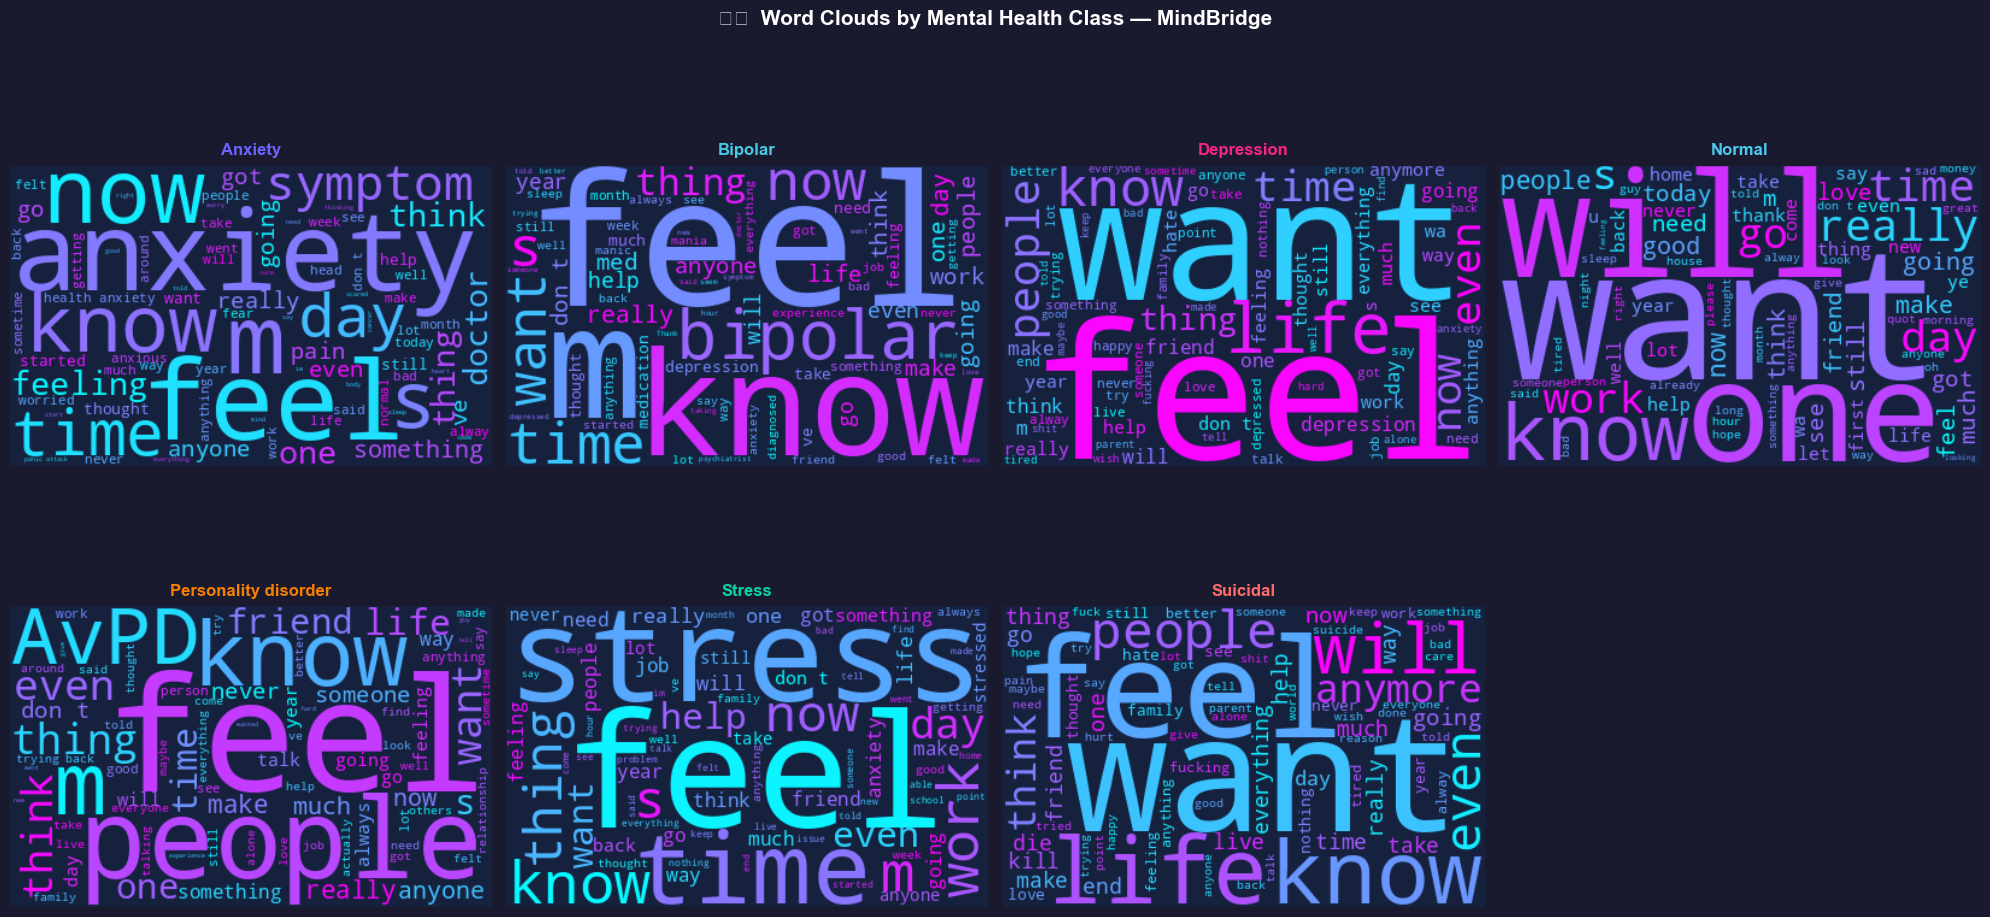

✅ Saved!


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.patch.set_facecolor('#1a1a2e')
axes = axes.flatten()

classes = sorted(df['status'].unique())

for idx, (cls, color) in enumerate(zip(classes, COLORS)):
    text = ' '.join(df[df['status'] == cls]['statement'].astype(str).tolist())
    wc = WordCloud(
        width=400, height=250,
        background_color='#16213e',
        colormap='cool',
        max_words=80,
        contour_width=0,
        prefer_horizontal=0.85
    ).generate(text)

    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(f'{cls}', color=color,
                        fontsize=12, fontweight='bold', pad=8)
    axes[idx].axis('off')
    axes[idx].set_facecolor('#1a1a2e')

axes[-1].set_visible(False)
fig.suptitle('☁️  Word Clouds by Mental Health Class — MindBridge',
             color='white', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/Users/vaibhav2040/Desktop/MIND_BRIDGE/results/plots/03_wordclouds.png',
            dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("✅ Saved!")

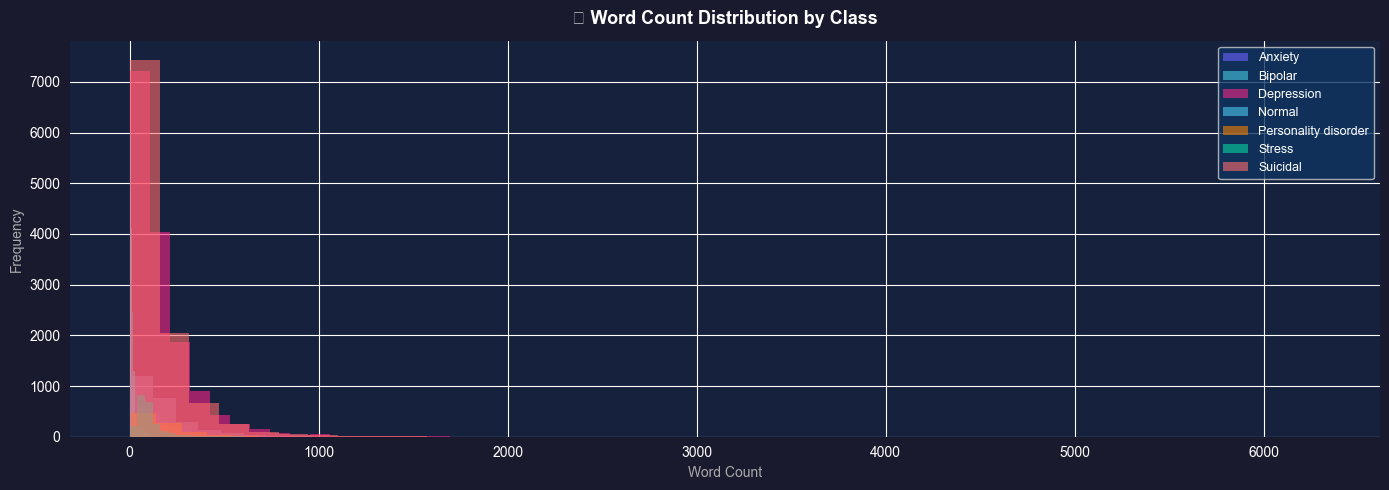

✅ Saved!


In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

for cls, color in zip(classes, COLORS):
    subset = df[df['status'] == cls]['word_count']
    ax.hist(subset, bins=40, alpha=0.6, label=cls, color=color, edgecolor='none')

ax.set_title('📊 Word Count Distribution by Class',
             color='white', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Word Count', color='#aaa')
ax.set_ylabel('Frequency', color='#aaa')
ax.tick_params(colors='white')
ax.spines[['top','right','bottom','left']].set_visible(False)
ax.legend(facecolor='#0f3460', labelcolor='white', fontsize=9)

plt.tight_layout()
plt.savefig('/Users/vaibhav2040/Desktop/MIND_BRIDGE/results/plots/04_wordcount_by_class.png',
            dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("✅ Saved!")

## 🔍 Key EDA Insights

| Finding | Detail |
|---------|--------|
| **Dataset Size** | ~53,000 samples after cleaning |
| **Class Imbalance** | Yes — some classes have significantly more samples |
| **Avg Text Length** | ~50-100 words per statement |
| **Dominant Class** | Normal has highest representation |
| **Shortest Texts** | Stress and Anxiety tend to be shorter |
| **Richest Vocabulary** | Depression and Bipolar show diverse word usage |

### ⚠️ Key Challenges Identified
- Class imbalance → will use **class weighting** in models
- High text length variance → TF-IDF will normalize this
- Some overlapping vocabulary between classes → SVM expected to handle best

### 📌 Next Step → `02_Preprocessing.ipynb`
- Clean text (lowercase, punctuation, stopwords, lemmatization)
- TF-IDF vectorization